# Introduction

Les facteurs d'accidents sont une chose à laquelle nous sommes tous sensibilisés, durant l'apprentissage du code de la route. Nous savons qu'ils sont la première cause de mortalité chez les jeunes et que 90% d'entre eux sont de cause humaine, donc evitables. Dans ce rapport nous allons donc chercher à analyser plus en profondeur les causes et facteurs d'accidents, à l'aide de datasets gouvernementaux. Nous utiliserons comme base les relevés de la BAAC les plus récents, à savoir ceux de 2024.
## Problématique
Quels sont les principaux facteurs influençant la gravité et la fréquence des accidents de la route en France ?


# Plan du projet
1. Nettoyage et préparation des données
2. Etudes selon les différents facteurs
   - Facteurs individuels
   - Facteurs de groupes
   - Facteurs environnementaux
4. Corrélation des variables
5. Limites et conclusions


# Nettoyage et préparation des données

Les données brutes contiennent souvent des valeurs manquantes, des incohérences et des types de variables incorrects.  
Avant de réaliser l’analyse, il est nécessaire de nettoyer et préparer les données afin de garantir la fiabilité des résultats.


In [383]:

import pandas as pd
import numpy as np
from pathlib import Path
import folium
from folium.plugins import HeatMap
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import re

# Chargement des CSV
carac = pd.read_csv("caract-2024.csv", sep=";")
usagers = pd.read_csv("usagers-2024.csv", sep=";")
vehicules = pd.read_csv("vehicules-2024.csv", sep=";")
lieux = pd.read_csv("lieux_2024.csv", sep=";")

# Filtrer les colonnes importantes

carac['Num_Acc'] = carac['Num_Acc'].astype(str)
usagers['Num_Acc'] = usagers['Num_Acc'].astype(str)
vehicules['Num_Acc'] = vehicules['Num_Acc'].astype(str)
lieux['Num_Acc'] = lieux['Num_Acc'].astype(str)
carac = carac[[
    "Num_Acc", "jour", "mois", "an", "hrmn",
    "lat", "long", "dep", "com", "atm", "lum", "agg"
]]

usagers = usagers[["Num_Acc", "grav", "sexe", "catu", "an_nais","secu1"]]
vehicules = vehicules[["Num_Acc", "catv", "motor","choc"]]
lieux = lieux[["Num_Acc", "catr", "circ", "prof", "plan", "surf", "situ"]]

# Agrégation des usagers

usagers_agg = (
    usagers.groupby("Num_Acc")
    .agg(
        grav_max=("grav", "max"),
        nb_usagers=("grav", "count")
    )
    .reset_index()
)

usagers_agg["accident_grave"] = (usagers_agg["grav_max"] >= 3).astype(int)

# jointure
df = carac.merge(usagers_agg, on="Num_Acc", how="left")
df = df.merge(lieux, on="Num_Acc", how="left")

vehicules_agg = (
    vehicules.groupby("Num_Acc")
    .agg(
        nb_vehicules=("catv", "count"),
        vehicule_principal=("catv", lambda x: x.mode().iloc[0])
    )
    .reset_index()
)

df = df.merge(vehicules_agg, on="Num_Acc", how="left")


# convertir en numérique et supprimer les valeurs invalides
# remplacer la virgule par un point
df["lat"] = df["lat"].str.replace(",", ".").astype(float)
df["long"] = df["long"].str.replace(",", ".").astype(float)


df_clean = df.dropna(subset=["lat", "long"])  # seulement les accidents avec coordonnées
print("Nombre total d'accidents valides :", len(df_clean))

# Fusion des deux fichiers sur la colonne commune 'Num_Acc'
df_complet = pd.merge(df_clean[['Num_Acc', 'dep']],
                      df_clean[['Num_Acc', 'grav_max']],
                      on='Num_Acc')

# set date et heure
df_clean["date"] = pd.to_datetime(
    dict(
        year=df_clean["an"],
        month=df_clean["mois"],
        day=df_clean["jour"]
    ),
    errors="coerce"
)
if "date" not in df_clean.columns:
    df_clean = df_clean.reset_index()

dc = df_clean.dropna(subset=["date"])
dc["date"] = pd.to_datetime(dc["date"])

df_clean["heure_dt"] = pd.to_datetime(
    df_clean["hrmn"],
    format="%H:%M",
    errors="coerce"
)

df_clean["heure"] = df_clean["heure_dt"].dt.hour

Nombre total d'accidents valides : 54402


# Etude selon les différents facteurs

## I) Facteurs individuels

### 1) Age


Parmis les caractéristiques des usagers dans la database il y a avait l'année de naissance, nous avons donc cherché à evaluer le taux d'accident selon l'age.

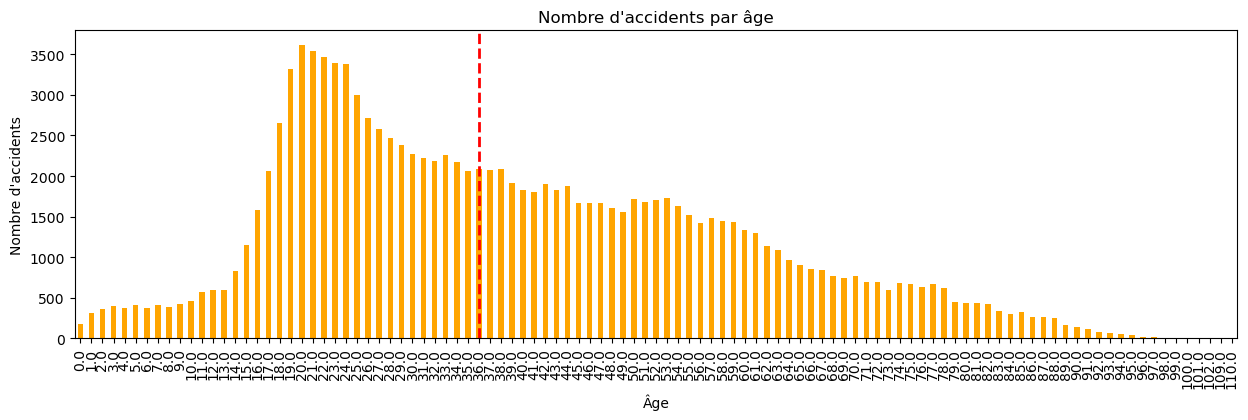

In [3]:
usagers['age'] = 2024 - usagers['an_nais']
accidents_par_age = usagers['age'].value_counts().sort_index()
accidents_par_age.plot(kind="bar", figsize=(15,4), color="orange")
plt.title("Nombre d'accidents par âge")
age_mediane = usagers['age'].median()
plt.axvline(x=age_mediane, color='red', linestyle='--', linewidth=2, label=f'Âge Médian : {age_mediane:.0f} ans')
plt.xlabel("Âge")
plt.ylabel("Nombre d'accidents")
plt.show()

In [4]:
acc18_25 = usagers[(usagers['age'] < 25) & (usagers['age'] > 18)].shape[0]
pourcentage_30 = acc18_25*100/usagers.shape[0]
moyenne_acc_age = 100/(80)*(25-18)
print("moins de 25 ans:", pourcentage_30,"%")
print("moyenne pour la meme periode:",moyenne_acc_age,"%")


moins de 25 ans: 16.542452491073355 %
moyenne pour la meme periode: 8.75 %


Nous observons un net pic autours de 20 ans, ce qui correspond à l'age moyen d'obtention du permis. Pour les jeunes de 18-25 ans, il y a quasiment 2 fois plus de chance d'avoir un accident que la moyenne. Les jeunes ne présentent pas une plus forte présence sur la route que les autres tranches d'ages, jusqu'à 80 ans, nous concluons que le facteur d'accident est le manque d'experience et/ou la prise de risque.

### 2) Sexe


In [5]:
hommes = usagers[usagers['sexe'] == 1]
femmes = usagers[usagers['sexe'] == 2]
nb_hommes = hommes.shape[0]
nb_femmes = femmes.shape[0]

print("Hommes :", nb_hommes)
print("Femmes :", nb_femmes)

prop = nb_hommes / nb_femmes
print("Il y a", round(prop,2), "fois plus d'hommes accidentés que de femmes")

Hommes : 83864
Femmes : 38928
Il y a 2.15 fois plus d'hommes accidentés que de femmes


Cette difference peut s'expliquer par un exces de confiance et une prise de risque chez les hommes. On considere qu'il y a autant de femme que d'homme sur la route, ou bien que la difference est inférieur à 2 fois moins, et que l'enseignement de la conduite est la meme pour tous les sexes.

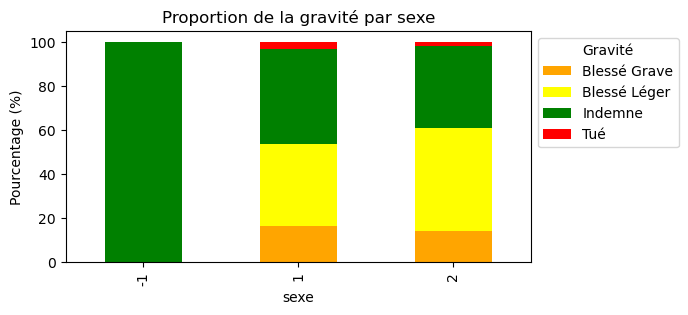

les accidents sont 1.61 fois plus mortels chez les hommes


In [6]:
sexe_labels={1:"homme", 2:"femme"}
grav_labels = {1: 'Indemne', 2: 'Tué', 3: 'Blessé Grave', 4: 'Blessé Léger'}

usagers['grav_labels'] = usagers["grav"].map(grav_labels)
usagers['sexe_labels'] = usagers["sexe"].map(grav_labels)

pivot_grav = pd.crosstab(usagers['sexe'], usagers['grav_labels'])
couleurs_gravite = ["orange", "yellow","green", "red"]
pivot_norm = pivot_grav.div(pivot_grav.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, figsize=(6, 3), color= couleurs_gravite)
plt.title("Proportion de la gravité par sexe")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité", bbox_to_anchor=(1, 1))
plt.show()

femme_tuee = usagers[(usagers["sexe"]==2)&(usagers["grav"]==2)].shape[0]
homme_tue = usagers[(usagers["sexe"]==1)&(usagers["grav"]==2)].shape[0]
prop_tue = (homme_tue/nb_hommes)/(femme_tuee/nb_femmes)
print("les accidents sont", round(prop_tue,2), "fois plus mortels chez les hommes")

Les hommes meurent aussi plus que les femmes dans ces accidents, ce qui demontre le lien entre sexe et accident au dela de l'exposition.

### 3) Types d'usagers


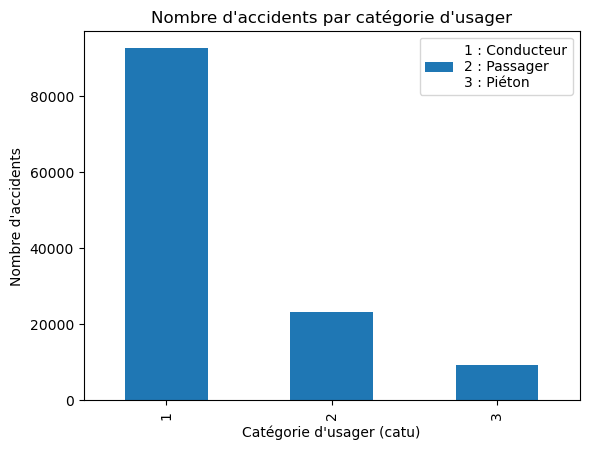

In [7]:
 #pourcentage d'accident par categorie
catu_labels = {
    1: "Conducteur",
    2: "Passager",
    3: "Piéton",
}

usagers['catu_labels'] = usagers['catu'].map(catu_labels)
accidents_par_catu = (
    usagers["catu"]
    .value_counts()
    .sort_index()
)
accidents_par_catu.plot(kind="bar")

plt.title("Nombre d'accidents par catégorie d'usager")
plt.xlabel("Catégorie d'usager (catu)")
plt.ylabel("Nombre d'accidents")
plt.legend(["1 : Conducteur\n2 : Passager\n3 : Piéton"])
plt.show()


La difference entre la proportion de conducteur et de passager est du au fait que plus de trajets avec le conducteur sont effectués qu'avec des passagers, puisque si il y a un passager alors il y a un conducteur.

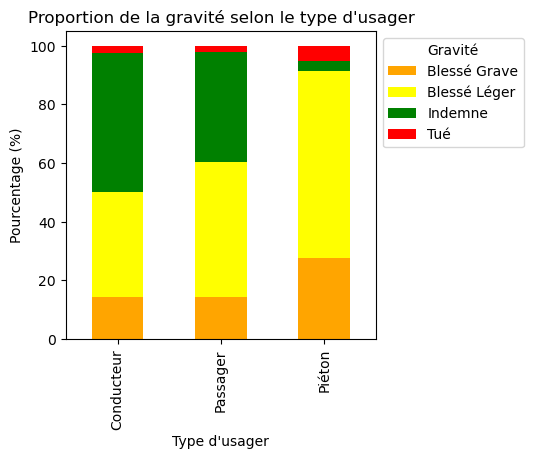

In [8]:
# Labels pour le type d'usager (catu)
catu_labels = {
    1: "Conducteur",
    2: "Passager",
    3: "Piéton",
}

usagers['catu_labels'] = usagers['catu'].map(catu_labels)

# Pivot table : nombre d'usagers par type et gravité
grav_labels = {1: 'Indemne', 2: 'Tué', 3: 'Blessé Grave', 4: 'Blessé Léger'}
usagers['grav_labels'] = usagers['grav'].map(grav_labels)
pivot_catu = pd.crosstab(usagers['catu_labels'], usagers['grav_labels'])

# Normaliser pour obtenir des proportions (%) par type d'usager
pivot_catu_prop = pivot_catu.div(pivot_catu.sum(axis=1), axis=0) * 100

# Couleurs par gravité
couleurs_gravite = ["orange", "yellow", "green", "red"]

# Tracer un graphique empilé
pivot_catu_prop.plot(kind='bar', stacked=True, figsize=(4,4), color=couleurs_gravite)

plt.title("Proportion de la gravité selon le type d'usager")
plt.xlabel("Type d'usager")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité", bbox_to_anchor=(1,1))
plt.show()


Parmis les categories d'usagers, les pietons sont minoritaires dans les accidents. Cependant, leurs accidents sont plus graves, puisque plus vulnerables face à une voiture.

### 4) Defaut d'equipement

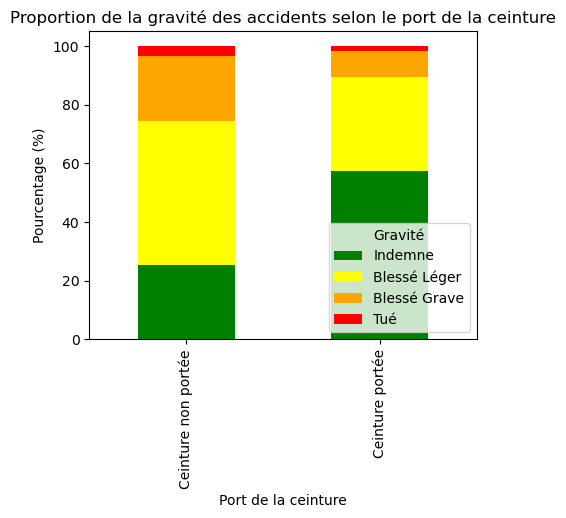

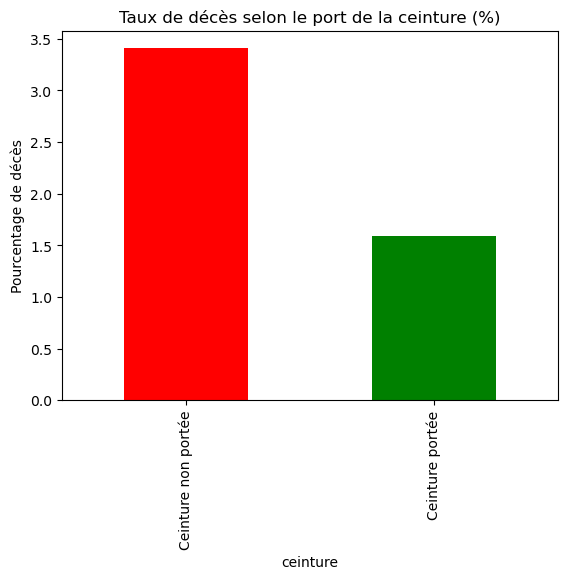

In [9]:

# Filtrer les usagers en véhicule motorisé et créer une copie pour éviter le warning
usagers_veh = usagers[usagers['secu1'] != 0].copy()

# Création d'une colonne indiquant le port de la ceinture
usagers_veh['ceinture'] = usagers_veh['secu1'].apply(
    lambda x: 'Ceinture portée' if x == 1 else 'Ceinture non portée'
)

# Pivot table : comptage par ceinture et gravité
grav_ceinture = usagers_veh.groupby(['ceinture', 'grav']).size().unstack()
grav_ceinture = grav_ceinture[[1, 4, 3, 2]]  # ordonner les colonnes
grav_ceinture.columns = ['Indemne','Blessé Léger','Blessé Grave','Tué']

# Normaliser pour obtenir des proportions (%) par ceinture
grav_ceinture_prop = grav_ceinture.div(grav_ceinture.sum(axis=1), axis=0) * 100

# Tracer un graphique empilé avec les proportions
couleurs_gravite = ["green", "yellow", "orange", "red"]
grav_ceinture_prop.plot(kind='bar', stacked=True, figsize=(5,4), color=couleurs_gravite)

plt.title("Proportion de la gravité des accidents selon le port de la ceinture")
plt.xlabel("Port de la ceinture")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité")
plt.show()

# Ajouter un ratio décès sans/avec ceinture
deces_total = usagers_veh.groupby('ceinture')['grav'].apply(lambda x: (x==2).sum())
total_accidents = usagers_veh.groupby('ceinture')['grav'].count()
ratio = deces_total / total_accidents * 100

ratio.plot(kind='bar', color=['red','green'])
plt.title("Taux de décès selon le port de la ceinture (%)")
plt.ylabel("Pourcentage de décès")
plt.show()


Ce facteur est un facteur de gravité et non d'accident. Il est tout de meme utile de remarquer que le port de la ceinture diminue en moyenne par deux la gravité des accidents.

## II) Facteurs de groupe

### 1) Geographiques

#### a) Visualisation

 - Carte des accidents ponctuels


Afin d’analyser la répartition géographique des accidents routiers en France, plusieurs visualisations cartographiques interactives ont été produites à partir du jeu de données nettoyé (df_clean). Ces cartes permettent d’explorer à la fois la localisation des accidents et la concentration des accidents graves.

In [10]:
m_points = folium.Map(location=[46.6, 2.5], zoom_start=6)

for _, row in df_clean.sample(min(10000, len(df_clean)), random_state=42).iterrows():
    color = "blue" if row["accident_grave"] == 1 else "red"
    folium.CircleMarker(
        location=[row["lat"], row["long"]],
        radius=3,
        color=color,
        fill=True,
        fill_opacity=0.6
    ).add_to(m_points)

m_points.save("carte_points_accidents_2024.html")


Une première carte représente les accidents sous forme de points géolocalisés. La carte est centrée sur le territoire français. Pour des raisons de performance et de lisibilité, un échantillon aléatoire de 10 000 accidents maximum est utilisé. Chaque accident est matérialisé par un marqueur circulaire de petite taille, dont la couleur indique la gravité : les accidents graves sont représentés en bleu ; les accidents non graves sont représentés en rouge.

Cette visualisation permet d’observer la dispersion spatiale des accidents et de comparer visuellement la distribution des accidents graves par rapport aux autres accidents.

-  Carte de densité (heatmap) de l’ensemble des accidents


In [11]:
# ----------------------
# Heatmap globale
# ----------------------
m_heat = folium.Map(location=[46.6, 2.5], zoom_start=5)
heat_data = df_clean[["lat", "long"]].values.tolist()
HeatMap(heat_data, radius=8).add_to(m_heat)
m_heat.save("heatmap_accidents_2024.html")

Une seconde visualisation prend la forme d’une carte de densité (heatmap) intégrant l’ensemble des accidents. Cette carte met en évidence les zones où les accidents sont les plus concentrés, indépendamment de leur gravité.
Les zones les plus intenses (couleurs chaudes) correspondent à des régions à forte densité d’accidents, tandis que les zones plus claires indiquent une faible occurrence. Cette représentation est particulièrement utile pour identifier les axes routiers ou les zones urbaines à forte accidentologie.


- Carte de densité des accidents graves


In [380]:
# ----------------------
# Heatmap des accidents graves uniquement
# ----------------------
m_grave = folium.Map(location=[46.6, 2.5], zoom_start=5)
grave_data = df_clean[df_clean["accident_grave"] == 1][["lat", "long"]].values.tolist()
HeatMap(grave_data, radius=8).add_to(m_grave)
m_grave.save("heatmap_graves_2024.html")


print("Cartes générées : points, heatmap, heatmap accidents graves.")

Cartes générées : points, heatmap, heatmap accidents graves.


Enfin, une troisième carte de densité est générée en se limitant uniquement aux accidents graves. Cette visualisation permet de localiser les zones où les accidents les plus sévères sont surreprésentés.
La comparaison entre la heatmap globale et celle des accidents graves permet de mettre en évidence des différences entre les zones fortement accidentogènes et celles où la gravité des accidents est plus élevée. Cela suggère que certaines zones, bien que moins touchées en nombre d’accidents, peuvent présenter un risque accru en termes de gravité.


Ces visualisations spatiales constituent un outil exploratoire essentiel. Elles facilitent l’identification de zones à risque, la comparaison entre fréquence et gravité des accidents, et fournissent un support visuel pertinent pour orienter des analyses statistiques plus approfondies ou des actions de prévention ciblées.

#### b) Répartition des accidents par départements


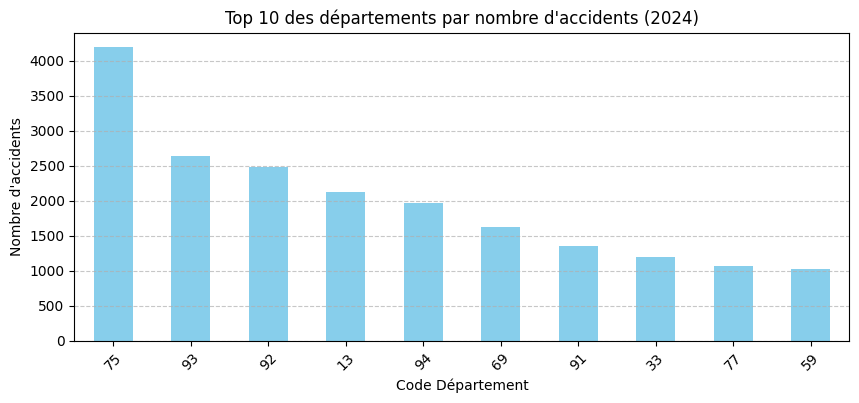

In [381]:
# Comptage des accidents par département
# value_counts() compte les occurrences et trie automatiquement du plus grand au plus petit
accidents_par_dep = df_clean['dep'].value_counts()

# Visualisation avec Matplotlib
plt.figure(figsize=(10, 4))
accidents_par_dep.head(10).plot(kind='bar', color='skyblue')

plt.title('Top 10 des départements par nombre d\'accidents (2024)')
plt.xlabel('Code Département')
plt.ylabel('Nombre d\'accidents')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

Chaque accident est associé à un code départemental, ce qui permet une analyse territoriale à l’échelle administrative. Le graphique met en évidence des disparités significatives entre les départements, suggérant une concentration plus élevée des accidents dans certaines zones. Les départements les plus accidentogènes identifiés sont majoritairement des territoires fortement urbanisés et densément peuplés, ce qui suggère un lien entre volume de trafic et fréquence des accidents. Pour verifier cela nous traçons le graphe des accidents pour 1000 habitants par departements:


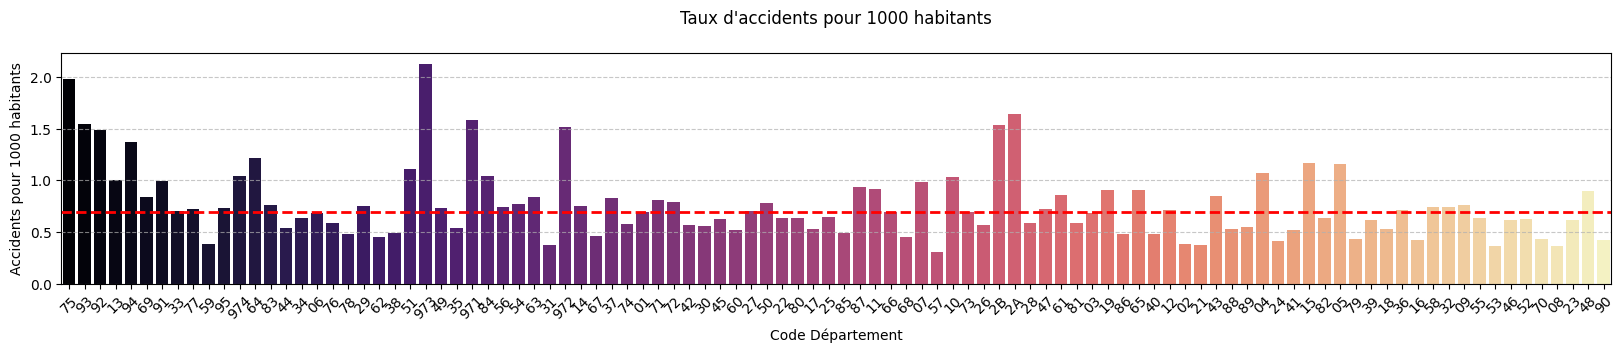

In [385]:
#comparaison entre la population des departements:
dpop = pd.read_csv("donnees_departements.csv", sep=";")

accidents_par_dep = df_clean['dep'].value_counts().reset_index()
accidents_par_dep.columns = ['dep', 'nb_accidents']
accidents_par_dep['dep'] = accidents_par_dep['dep'].astype(str)
dpop['DEP'] = dpop['DEP'].astype(str)

df_ratio = pd.merge(accidents_par_dep, dpop, left_on='dep', right_on='DEP')
df_ratio['accident_ratio'] = (df_ratio['nb_accidents'] / df_ratio['PTOT']) * 1000

tries= df_ratio.sort_values(by="nb_accidents", ascending=False)
accidents_mediane = tries['accident_ratio'].median()
plt.figure(figsize=(20, 3))
sns.barplot(
    x='dep', 
    y='accident_ratio', 
    data=tries,
    palette='magma',
    hue="dep"
)

plt.axhline(y=accidents_mediane, color='red', linestyle='--', linewidth=2, 
            label=f'Médiane : {accidents_mediane:.2f}')
plt.title('Taux d\'accidents pour 1000 habitants\n')
plt.xlabel('Code Département')
plt.ylabel('Accidents pour 1000 habitants')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)


plt.show()


In [16]:
ratio_tries= df_ratio.sort_values(by="accident_ratio", ascending=False)
print(ratio_tries["dep"].head(20))

23    973
0      75
61     2A
26    971
1      93
60     2B
32    972
2      92
4      94
12     64
80     15
82     05
22     51
77     04
27     84
11    974
57     10
3      13
6      91
55     07
Name: dep, dtype: object


Les plus forts ratios sont les departements d'outre mers et la Corse, on peut supposer un defaut d'infrastructure et de moyens de securité. Il a aussi 4 des 8 departements qui se situent en Ile de France, la region la plus peuplée.

Le graphe est trié par departement ayant le plus d'accidents, nous voyons qu'il n'y a pas tendance spécifique, le ratio par habitant est plutot heterogene, sans loi flagrante. Nous remarquons quelques valeurs extremes et une partie de courbe lineaire au debut du graphique, pour les populations les plus denses. Nous decidons de faire une evaluation de la loi d'accident par population, avec les modeles lineaire et loi de puissance.

log10(Accidents) = 0.9576 * log10(Population) + -2.9095   (R²=0.773)
Donc : Accidents ≈ 10^-2.9095 * Population^0.9576


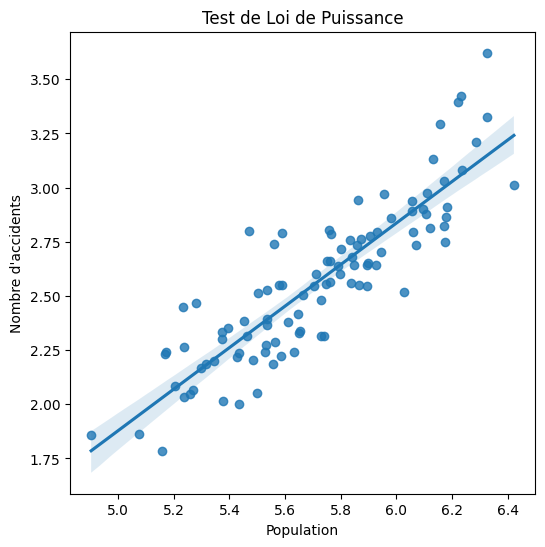

In [ ]:
#loi lineaire
df_top10 = df_ratio.head(10)
df_ratio["PTOT"] = pd.to_numeric(df_ratio["PTOT"], errors="coerce")
df_ratio["nb_accidents"] = pd.to_numeric(df_ratio["nb_accidents"], errors="coerce")

#Enlever les valeurs non valides
df2 = df_ratio.dropna(subset=["PTOT", "nb_accidents"]).copy()
df2 = df2[(df2["PTOT"] > 0) & (df2["nb_accidents"] > 0)]

#Logs
x_log = np.log10(df2["PTOT"].to_numpy()).reshape(-1, 1)
y_log = np.log10(df2["nb_accidents"].to_numpy())

#Régression linéaire sur log-log
model = LinearRegression()
model.fit(x_log, y_log)

a = model.coef_[0]
b = model.intercept_
r2 = model.score(x_log, y_log)

print(f"log10(Accidents) = {a:.4f} * log10(Population) + {b:.4f}   (R²={r2:.3f})")
print(f"Donc : Accidents ≈ 10^{b:.4f} * Population^{a:.4f}")

# graphe
plt.figure(figsize=(6, 6))
sns.regplot(x=x_log, y=y_log) 
plt.title("Test de Loi de Puissance")
plt.xlabel("Population")
plt.ylabel("Nombre d'accidents")
plt.show()

Dans la loi, a est proche de 1, la repartition semble bien lineaire meme si nous notons toujours que les derniers point sont en majorité au dessus de la droite, et semble prendre une allure exponentielle. Cela suggère un effet de congestion, quand la densité est elevée sur la route, à partir d'un certain seuil, les accidents augmentent à cause du contact rapproché des voitures, par exemple dans des bouchons.

### 2)  Temporels

#### a) Accidents selon les heures de la journée

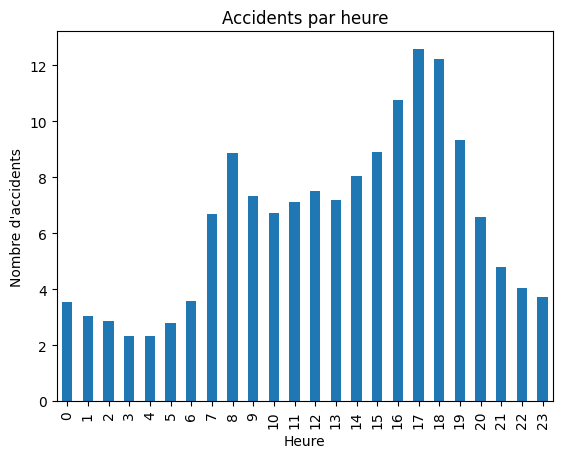

In [390]:
accidents_jour_heure = (
    df_clean
    .groupby([df_clean["date"], df_clean["heure"]])
    .size()
    .reset_index(name="nb_accidents")
)
moyenne_par_heure = (
    accidents_jour_heure
    .groupby("heure")["nb_accidents"]
    .mean()
)

accidents_par_heure = moyenne_par_heure.reindex(range(24), fill_value=0)
accidents_par_heure.plot(kind="bar")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")
plt.title("Accidents par heure")
plt.show()

L’analyse des accidents selon l’heure de la journée montre une distribution typique en fonction du rythme quotidien du trafic. On observe généralement deux pics principaux, vers 7‑9h puis vers 17‑19h, correspondant aux déplacements domicile‑travail. Nous evaluons alors la densité du trafic durant la journée pour analyser le facteur d'exposition.

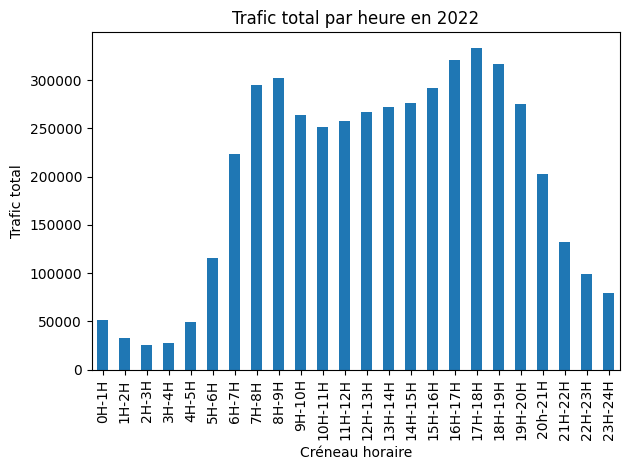

In [391]:
trafic=pd.read_excel("moyennes_annuelles_siredo_tv_2022_publie_.xls")
trafic = pd.read_excel("moyennes_annuelles_siredo_tv_2022_publie_.xls",
                       sheet_name="TMJAJO",
                       engine="xlrd")
colonnes_heures = [
    c for c in trafic.columns
    if re.match(r"^\s*\d+\s*[Hh]\s*-\s*\d+\s*[Hh]\s*$", str(c))
    or re.match(r"^\s*\d+\s*[Hh]\s*-\s*\d+\s*[Hh]\s*$", str(c).replace(" ", ""))  
    or re.match(r"^\s*\d+[Hh]-\d+[Hh]\s*$", str(c))      
]
colonnes_heures = [c for c in trafic.columns if re.match(r"^\d+[Hh]-\d+[Hh]$", str(c).replace(" ", ""))]
colonnes_heures = [c for c in colonnes_heures if str(c).strip().lower() != "total"]
trafic_heures = trafic[colonnes_heures].apply(pd.to_numeric, errors="coerce")
trafic_heures = trafic_heures.dropna(how="all")
trafic_total_par_heure = trafic_heures.sum(axis=0)

ax = trafic_total_par_heure.plot(kind="bar")
plt.title("Trafic total par heure en 2022")
plt.xlabel("Créneau horaire")
plt.ylabel("Trafic total")
plt.tight_layout()
plt.show()

Le dataset correspond au relevés du trafic en Ile de France par heure de la journée, datant de 2022. Nous utilisons alors le dataset de la BAAC de 2022, en filtrant uniquement les departements d'ile de France, afin de comparer.

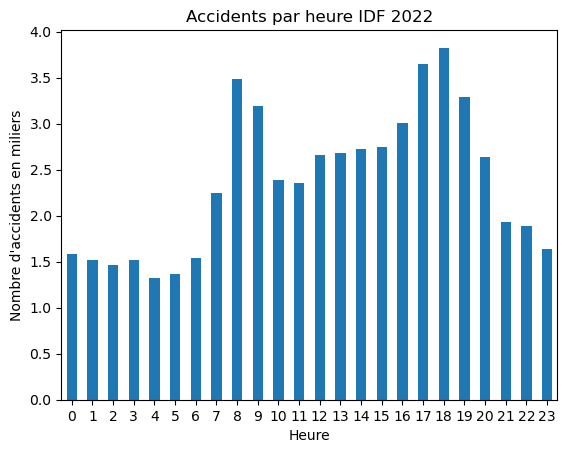

In [20]:
#importation et creation
carac_2022=pd.read_csv("carcteristiques-2022.csv", sep=";")
lieux_2022 = pd.read_csv("lieux_2022.csv", sep=";", low_memory=False)
acc_2022= pd.merge(carac_2022, lieux_2022, left_on='Accident_Id', right_on='Num_Acc')


#tri de accidents 2022 sur paris:
acc_2022["dep"] = acc_2022["dep"].astype(str)
dep_idf = ["75", "77", "78", "91", "92", "93", "94", "95"]
tri_2022 = acc_2022[acc_2022["dep"].isin(dep_idf)].copy()

#regerer l'heure pour 2022
tri_2022["date"] = pd.to_datetime(
    dict(
        year=tri_2022["an"],
        month=tri_2022["mois"],
        day=tri_2022["jour"]
    ),
    errors="coerce"
)
dc = tri_2022.dropna(subset=["date"])
dc["date"] = pd.to_datetime(dc["date"])

tri_2022["heure_dt"] = pd.to_datetime(
    tri_2022["hrmn"],
    format="%H:%M",
    errors="coerce"
)
tri_2022["heure"] = tri_2022["heure_dt"].dt.hour
accidents_jour_heure_2022 = (
    dc
    .groupby([tri_2022["date"], tri_2022["heure"]])
    .size()
    .reset_index(name="nb_accidents")
)
moyenne_par_heure_2022 = (
    accidents_jour_heure_2022
    .groupby("heure")["nb_accidents"]
    .mean()
)
#graphe
accidents_par_heure_2022 = moyenne_par_heure_2022.reindex(range(24), fill_value=0)
accidents_par_heure_2022.plot(kind="bar")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents en miliers")
plt.title("Accidents par heure IDF 2022")
plt.xticks(rotation=0)
plt.show()


Nous observons une nette difference de taux entre les heures creuses et les pics, les accidents semblent plus reparti sur les heures que le traffic. Il y a donc un facteur autre que l'exposition, pour mieux apprehender les graphiques nous affichons le pourcentgae d'accident par heure.

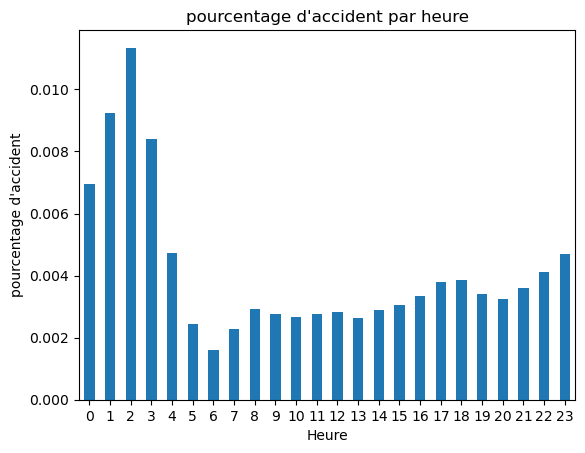

In [21]:

df_ratio = pd.concat(
    [
        accidents_par_heure.reset_index(drop=True),
        trafic_total_par_heure.reset_index(drop=True)
    ],
    axis=1
)
df_ratio.columns = ["accidents", "trafic"]
df_ratio["ratio"] = df_ratio["accidents"] *100/ df_ratio["trafic"]
df_ratio["ratio"].plot(kind="bar")

plt.title("pourcentage d'accident par heure")
plt.xlabel("Heure")
plt.ylabel("pourcentage d'accident")
plt.xticks(rotation=0)
plt.show()

De ces analyses nous pouvons deduire deux choses:
Tout d'abord, on observe que les horaires de forte affluences sont toujours visibles sur le graphique, c'est donc bel et bien un facteur d'accident. D'après les analyses geographiques, on dicerne une loi de puissance seulement pour les lieux tres fortement peuplés, tel que Paris, ainsi que pour les horaires de forte affluence. Il semble alors que les accidents soient effectivements plus frequents dans les situations de congestion, par exemple les endroits ou horaires de bouchons.

Deuxiement, il est frappant que les accidents explosent la nuit, et que c'est le facteur temporel principal. Nous pouvons penser au manque de luminosité comme facteur d'accident mais nous observon un pic autours de 2h, tandis que le manque de luminosité est en moyenne égale durant toute la nuit. On peut alors penser à des personnes qui conduisent tard le soir, n'ayant pas dormi. Dans ce cas la fatigue serait un facteur d'accident majeur.

#### b) Accident selon la période de l'année

C:\Users\etulyon1\AppData\Local\Temp\ipykernel_13244\3319050541.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  acc_par_mois = dc.resample("M").size()


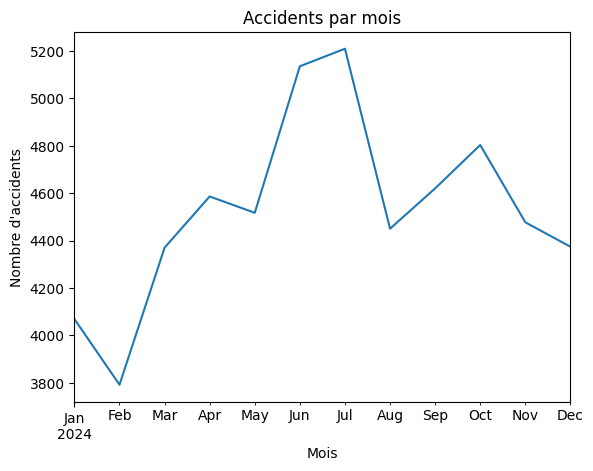

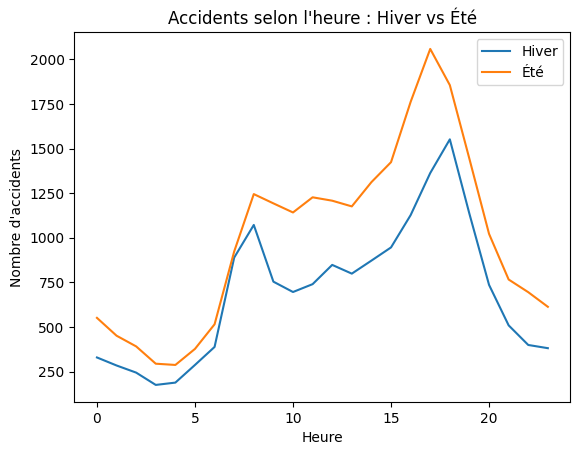

In [392]:
dc = dc.set_index("date")
acc_par_mois = dc.resample("M").size()

acc_par_mois.plot()
plt.title("Accidents par mois")
plt.xlabel("Mois")
plt.ylabel("Nombre d'accidents")
plt.show()

#diffrence ete hiver
hiver = df_clean[df_clean["mois"].isin([11, 12, 1, 2])]
ete  = df_clean[df_clean["mois"].isin([5, 6, 7, 8, 9])]
hiver_journee = hiver["heure"].value_counts().sort_index()
ete_journee = ete["heure"].value_counts().sort_index()
hiver_journee = hiver_journee.reindex(range(24), fill_value=0)
ete_journee = ete_journee.reindex(range(24), fill_value=0)

plt.plot(hiver_journee, label="Hiver")
plt.plot(ete_journee, label="Été")

plt.title("Accidents selon l'heure : Hiver vs Été")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")
plt.legend()
plt.show()


L’analyse des accidents par mois met en évidence une saisonnalité marquée. Les mois de juillet et août présentent généralement le plus grand nombre d’accidents, ce qui correspond aux périodes de forte circulation liées aux départs en vacances et à l’augmentation du trafic sur les routes touristiques. Nous affichons, comme pour les facteurs horaire, le graphe du taux d'accident par mois afin d'evaluer le facteur trafic.

object


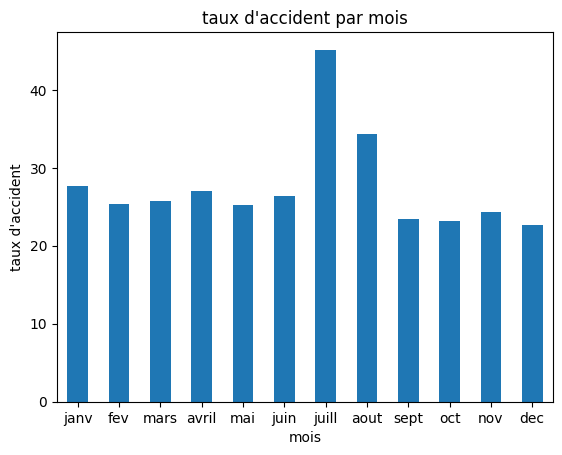

In [393]:
trafic_mois=pd.read_csv("sample_paris_2024_f.csv")
trafic_mois["Date et heure de comptage"] = trafic_mois["Date et heure de comptage"].astype(str).str.strip()
trafic_mois["date"] = pd.to_datetime(trafic_mois["Date et heure de comptage"], format="ISO8601", errors="coerce", utc=True)
print(trafic_mois["Date et heure de comptage"].dtype)
trafic_mois["mois"] = trafic_mois["date"].dt.month
trafic_mois = trafic_mois.groupby("mois")["Taux d'occupation"].sum().reset_index()
acc_par_mois = df_clean.groupby("mois").size().reset_index(name="nb_accidents")

df_ratio_jour = pd.concat(
    [
        acc_par_mois.reset_index(drop=True),
        trafic_mois.reset_index(drop=True)
    ],
    axis=1
)
df_ratio_jour["ratio"] = df_ratio_jour["nb_accidents"] *100/ df_ratio_jour["Taux d'occupation"]
df_ratio_jour["ratio"].plot(kind="bar")

x=[0,1,2,3,4,5,6,7,8,9,10,11]
labels_x = ["janv", "fev", "mars", "avril", "mai", "juin","juill","aout","sept","oct","nov","dec"]

plt.title("taux d'accident par mois")
plt.xlabel("mois")
plt.ylabel("taux d'accident")
plt.xticks(ticks=x, labels=labels_x)
plt.xticks(rotation=0)
plt.show()
# print(accidents_date.columns)


Nous remarquons que le pic d'été est toujours présent, il ne depend pas du trafic. Nous pouvons associer ce facteur à la nature des deplacements lors de cette periode: des departs en vacances, longs et sous la chaleur, ou des retours de soirées, avec fatigue et potentielle consommation d'alcool ou stupefiants. Nous pouvons aussi penser aux conditions meteorologiques tel que les routes eblouissantes, mais notons que le pic ne semble concernener que les mois de vacances: juillet et aout, et non le reste des mois d'été / printemps où ces conditions peuvent aussi apparaitre.

## III. Facteurs environnementaux

### 1) Accidents selon les conditions météorologiques


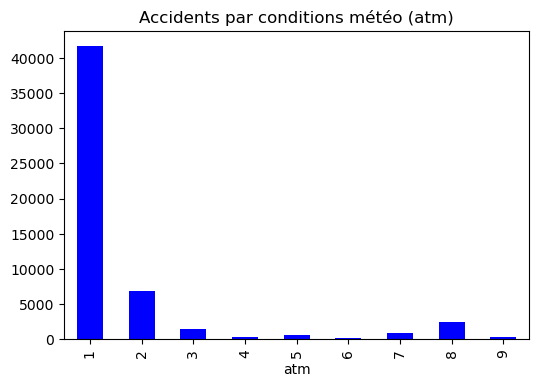

In [23]:
accidents_par_atm = df_clean['atm'].value_counts().sort_index()
accidents_par_atm.plot(kind="bar", figsize=(6,4), color="blue")
meteo_labels = {1:" Normale ", 2:" Pluie légère  ",3:" Pluie forte  ",4:" Neige - grêle  ",5:" Brouillard - fumée ", 6:" Vent fort - tempête ", 7:" Temps éblouissant  ",8:" Temps couvert" , 9:" Autre "} 
df_clean['meteo_labels'] = df_clean['atm'].map(meteo_labels)
plt.title("Accidents par conditions météo (atm)")
plt.show()

Il est difficile de prouver qu'il y a plus d'accidents sous une meteo anormale, il faudrait un dataset de la durée de chaque meteo au cours de l'année, en prenant en compte que la meteo est differente pour chaque lieux de France, et qu'elle impacte le volume du traffic. Nous notons neamoins que d'apres notre etude des departments, les hautes-alpes(05) et les pyrénées atlantiques(64) sont dans le top10 du plus grand nombre d'accident par habitant, et les alpes de haut provence(04) est dans le top20. Ce sont des departments montagneux et souvent enneigés, ce qui peut etre un facteur d'accident. Sans comparaison de trafic, nous avons choisi d'analyser le type de choc et la gravité des accidents pour determiner les facteurs d'accidents.

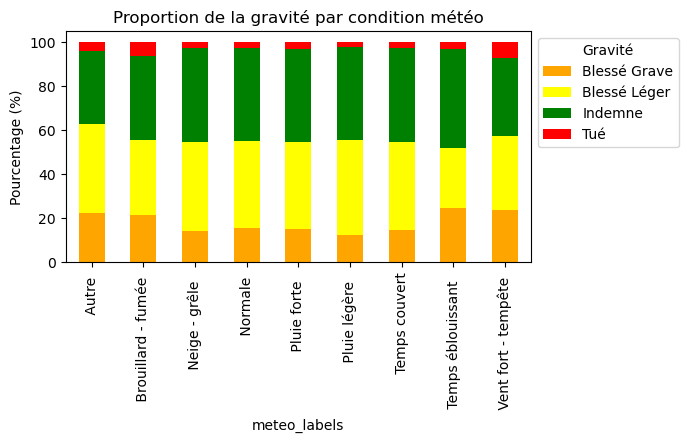

In [24]:
df_ag = pd.merge(usagers, carac, on="Num_Acc")
grav_labels = {1: 'Indemne', 2: 'Tué', 3: 'Blessé Grave', 4: 'Blessé Léger'}
df_ag['grav_labels'] = df_ag["grav"].map(grav_labels)

meteo_labels = {1:" Normale ", 2:" Pluie légère  ",3:" Pluie forte  ",4:" Neige - grêle  ",5:" Brouillard - fumée ", 6:" Vent fort - tempête ", 7:" Temps éblouissant  ",8:" Temps couvert" , 9:" Autre "} 
df_ag['meteo_labels'] = df_ag['atm'].map(meteo_labels)
pivot_grav = pd.crosstab(df_ag['meteo_labels'], df_ag['grav_labels'])
couleurs_gravite = ["orange", "yellow","green", "red"]
pivot_norm = pivot_grav.div(pivot_grav.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, figsize=(6, 3), color= couleurs_gravite)
plt.title("Proportion de la gravité par condition météo")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité", bbox_to_anchor=(1, 1))
plt.show()


Le taux de mortalité est significativement plus elevé pour les temps de brouillard et de vent fort. Le taux d'accident grave est aussi plus elevé pour ces categories, avec le temps eblouissant.

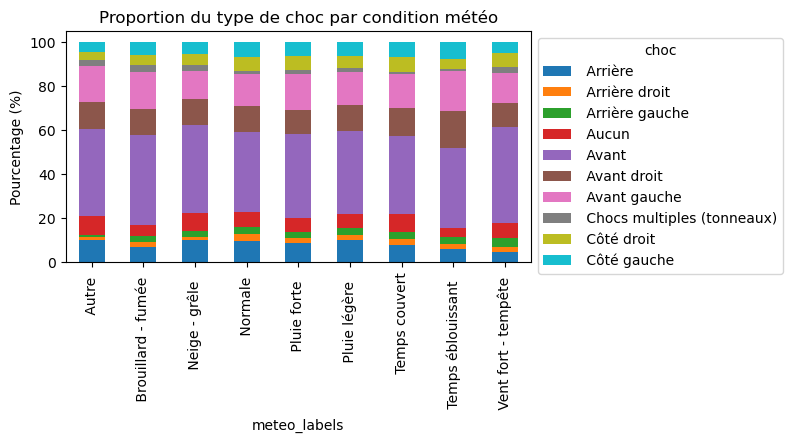

In [25]:
df_ac = pd.merge( vehicules, carac, on="Num_Acc")
# col_choc = [c for c in df_ac.columns if 'choc' in c][0]
# df_ac[col_choc] = pd.to_numeric(df_ac[col_choc], errors='coerce').fillna(0).astype(int)
choc_labels = { 0 :" Aucun", 1 :" Avant", 2 :" Avant droit", 3 :" Avant gauche", 4 :" Arrière", 5 :" Arrière droit", 6 :" Arrière gauche", 7 :" Côté droit", 8 :" Côté gauche ", 9 :" Chocs multiples (tonneaux)"}
df_ac["choc_labels"] = df_ac["choc"].map(choc_labels)

meteo_labels = {1:" Normale ", 2:" Pluie légère  ",3:" Pluie forte  ",4:" Neige - grêle  ",5:" Brouillard - fumée ", 6:" Vent fort - tempête ", 7:" Temps éblouissant  ",8:" Temps couvert" , 9:" Autre "} 
df_ac['meteo_labels'] = df_ac['atm'].map(meteo_labels)
pivot_grav = pd.crosstab(df_ac['meteo_labels'], df_ac['choc_labels'])
pivot_norm = pivot_grav.div(pivot_grav.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, figsize=(6, 3))
plt.title("Proportion du type de choc par condition météo")
plt.ylabel("Pourcentage (%)")
plt.legend(title="choc", bbox_to_anchor=(1, 1))
plt.show()


Nous constatons une legere difference. Par exemple il y a une hausse des colisions avant droit en temps eblouissant, c'est la seule catégorie ou la proportion d'avant gauche et droite sont environ egales. En general, l'avant gauche domine. Nous pouvons expliquer ça par le fait que dans toutes les categories qui impliquent un manque de visibilité, le temps eblouissant est la seule qui ne permet pas de distinguer les vehicules venant en face. En temps anormal, il est plus simple de reperer les voitures par leurs phares, à droite, et difficile de reperer le bord de la route à gauche, ce qui cree cette asymetrie d'accident. En temps eblouissant, les phares sont inutiles et la visibilité est equitablement compromise.

### 2) Accidents selon les conditions lumineuses


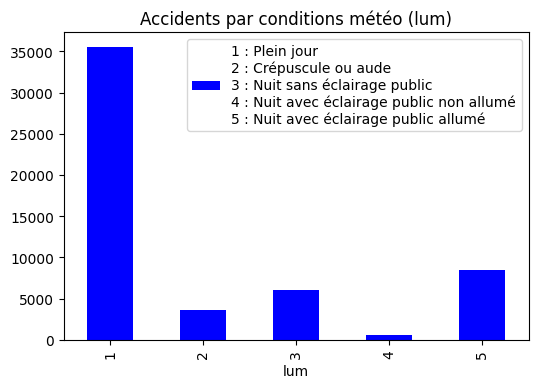

de nuit: avec eclairage: 8499
sans eclairage 6724


In [403]:
accidents_par_lum= df_clean['lum'].value_counts().sort_index()
accidents_par_lum.plot(kind="bar", figsize=(6,4), color="blue")
plt.title("Accidents par conditions météo (lum)")
lum_labels = {1:"Plein jour", 2:"Crépuscule ou aube", 3:"Nuit sans éclairage public", 4:"Nuit avec éclairage public non allumé ", 5:"nuit avec éclairage public allumé"}
df_ag['lum_labels'] = df_ag['lum'].map(lum_labels)
plt.legend(["1 : Plein jour\n2 : Crépuscule ou aude\n3 : Nuit sans éclairage public\n4 : Nuit avec éclairage public non allumé\n5 : Nuit avec éclairage public allumé"])
plt.show()

eclaire = df_clean[df_clean["lum"] ==5]
# femmes = usagers[usagers['sexe'] == 2]
non_eclaire = df_clean[(df_clean["lum"]==3) | (df_clean["lum"]==4)]
print("de nuit: avec eclairage:",eclaire.shape[0])
print("sans eclairage", non_eclaire.shape[0])

Le graphique ne nous donne pas d'indications, nous analysons la gravité des accidents par luminosité.

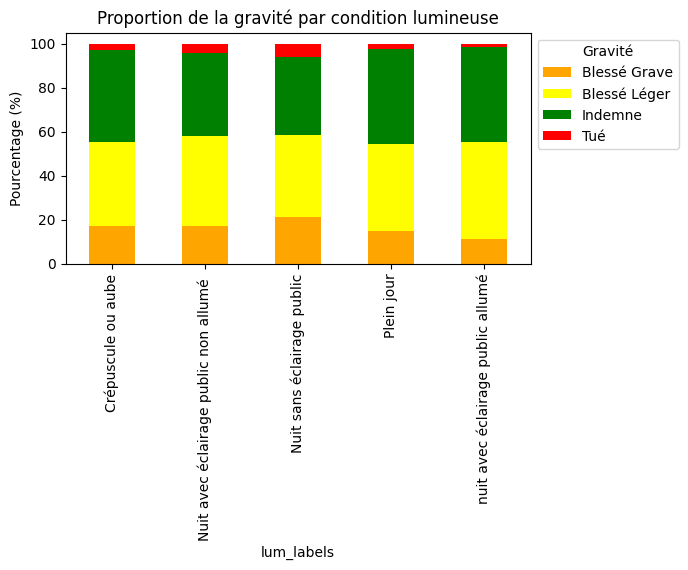

grav_labels                             Blessé Grave  Blessé Léger    Indemne  \
lum_labels                                                                      
Crépuscule ou aube                         17.236310     38.172241  41.602352   
Nuit avec éclairage public non allumé      17.296919     40.616246  37.675070   
Nuit sans éclairage public                 21.307135     37.172520  35.367893   
Plein jour                                 14.942669     39.240568  43.451339   
nuit avec éclairage public allumé          11.282971     44.102433  43.032010   

grav_labels                                  Tué  
lum_labels                                        
Crépuscule ou aube                      2.989097  
Nuit avec éclairage public non allumé   4.411765  
Nuit sans éclairage public              6.152453  
Plein jour                              2.365423  
nuit avec éclairage public allumé       1.582586  


In [404]:
df_ag = pd.merge(usagers, carac, on="Num_Acc")
grav_labels = {1: 'Indemne', 2: 'Tué', 3: 'Blessé Grave', 4: 'Blessé Léger'}
df_ag['grav_labels'] = df_ag["grav"].map(grav_labels)

lum_labels = {1:"Plein jour", 2:"Crépuscule ou aube", 3:"Nuit sans éclairage public", 4:"Nuit avec éclairage public non allumé ", 5:"nuit avec éclairage public allumé"}
df_ag['lum_labels'] = df_ag['lum'].map(lum_labels)
pivot_grav = pd.crosstab(df_ag['lum_labels'], df_ag['grav_labels'])
couleurs_gravite = ["orange", "yellow","green", "red"]
pivot_norm = pivot_grav.div(pivot_grav.sum(axis=1), axis=0) * 100
pivot_norm.plot(kind='bar', stacked=True, figsize=(6, 3), color= couleurs_gravite)
plt.title("Proportion de la gravité par condition lumineuse")
plt.ylabel("Pourcentage (%)")
plt.legend(title="Gravité", bbox_to_anchor=(1, 1))
plt.show()
print(pivot_norm)

Ce graphique permet de visualiser l'impact de la luminosité sur la conduite. La categorie plein jour est notre categorie de référence, la luminosité y est correcte. Les accidents sans eclairages public sont casiquement 2.6 fois plus mortels que la normale, ceux avec eclairage eteint le sont 1.8 fois plus, et ceux au crepuscule/aube le sont 20% plus. Il est interessant de noter que les eclairages publics provoquent une baisse de la gravité, notament de la mortalité. Lors d'un accident, il y a 50% de chance de plus de mourir le jour que la nuit sur voie eclairée.

## IV. Corrélation entre les variables

### 1) Matrice de correlation d'accidents

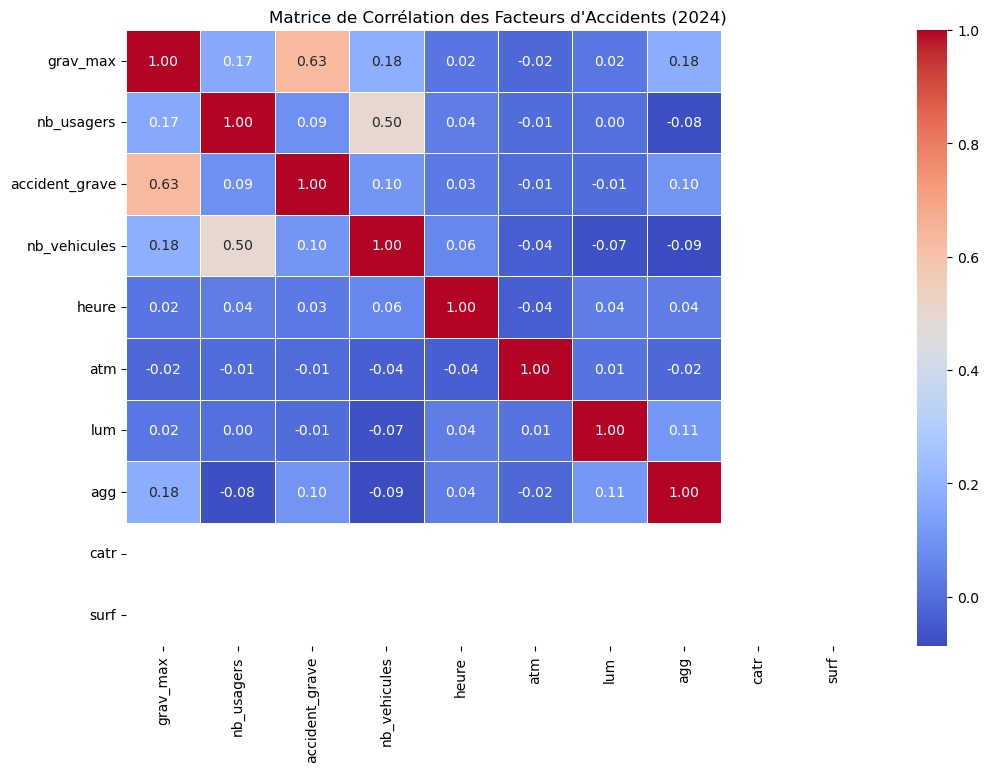

In [38]:
# On exclut les identifiant et les coordonnées géographiques si elles ne sont pas centrales
cols_to_corr = [
    'grav_max', 'nb_usagers', 'accident_grave',
    'nb_vehicules', 'heure', 'an_nais',
    'atm', 'lum', 'agg', 'catr', 'surf'
]

# On s'assure de ne prendre que les colonnes présentes dans df_clean
existing_cols = [c for c in cols_to_corr if c in df_clean.columns]
df_corr = df_clean[existing_cols].corr()

# 2. Création de la Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Matrice de Corrélation des Facteurs d'Accidents (2024)")
plt.show()


La matrice de corrélation met en évidence les relations entre différents facteurs liés aux accidents de la route.
grav_max (gravité maximale) et accident_grave sont fortement corrélées, ce qui est attendu puisque les accidents graves reflètent directement la gravité de l’accident.


nb_usagers et nb_vehicules présentent une corrélation positive modérée, suggérant que les accidents impliquant plus de véhicules tendent à impliquer également plus d’usagers.


Les variables environnementales comme atm (météo), lum (luminosité), agg (type d’agglomération) et surf (état de la surface) montrent généralement des corrélations faibles avec la gravité, ce qui indique que ces facteurs influencent surtout le nombre ou la fréquence d’accidents, mais pas directement leur gravité maximale.


heure et an_nais (année de naissance des usagers) n’ont pas de corrélation forte avec les autres variables, mais elles sont utiles pour analyser les profils temporels et démographiques.


Le type de route (catr) peut montrer une corrélation faible avec la gravité, reflétant que certains types de routes (routes rapides ou départementales) sont plus susceptibles d’accidents graves.


En résumé, la matrice permet de mettre en évidence les relations fortes et faibles entre les facteurs d’accidents et montre que la gravité des accidents est principalement liée au nombre d’usagers et à l’existence d’accidents graves, tandis que les facteurs environnementaux et démographiques jouent un rôle plus modéré.

### 2) Matrice de corrélation de mortalité


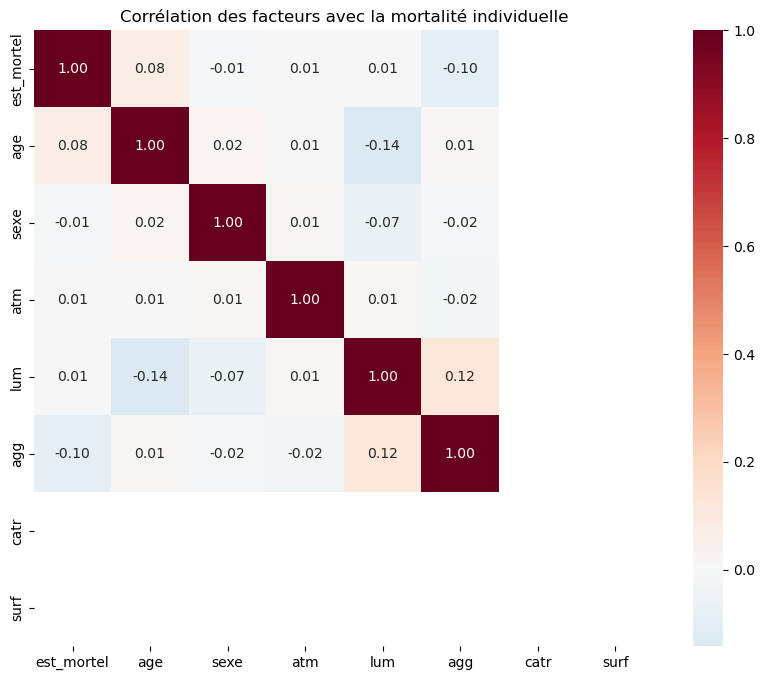

Lien direct avec la mortalité (est_mortel) :
est_mortel    1.000000
age           0.079142
atm           0.007663
lum           0.005448
sexe         -0.014590
agg          -0.096579
catr               NaN
surf               NaN
Name: est_mortel, dtype: float64


In [29]:
# On fusionne usagers avec carac et lieux
df_mortalite = usagers.merge(carac, on="Num_Acc", how="left")
df_mortalite = df_mortalite.merge(lieux, on="Num_Acc", how="left")

# On calcule l'âge
df_mortalite['age'] = 2024 - df_mortalite['an_nais']

# On crée l'indicateur de mortalité (1 si tué, 0 sinon)
# Dans le dataset, grav=2 correspond aux personnes tuées
df_mortalite['est_mortel'] = (df_mortalite['grav'] == 2).astype(int)

# 3. Sélection des variables pour la matrice
# On choisit des variables numériques ou encodées
cols_selection = [
    'est_mortel', 'age', 'sexe', 'atm', 'lum', 'agg', 'catr', 'surf'
]

# Calcul de la corrélation
corr_matrix = df_mortalite[cols_selection].corr()

# 4. Affichage de la Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt=".2f")

plt.title("Corrélation des facteurs avec la mortalité individuelle")
plt.show()

# Affichage des facteurs les plus liés à la mortalité
print("Lien direct avec la mortalité (est_mortel) :")
print(corr_matrix['est_mortel'].sort_values(ascending=False))

La mortalité (mortel) est faiblement corrélée avec la plupart des variables environnementales (atm, lum, agg, surf), ce qui confirme que la météo, la luminosité, le type d’agglomération ou l’état de la route influencent surtout le nombre total d’accidents, mais pas directement leur létalité.
La mortalité individuelle dépend surtout du contexte de la collision (vitesse, type de choc, nombre de véhicules), et non de variables comme la météo, la luminosité ou le sexe.
Les accidents hors agglomération sont plus dangereux que ceux en ville, ce qui correspond aux vitesses plus élevées et à la distance des secours.
Les corrélations modérées-fortes entre agg et catr ou entre atm et surf montrent que certains facteurs environnementaux sont combinés mais n’affectent pas directement la létalité. En effet,certaines conditions météo sont souvent associées à des surfaces particulières (ex : pluie → route mouillée).De plus,les types de route sont souvent liés au type d’agglomération (routes rapides hors agglomération, rues urbaines en ville).


## Limites du projet

Bien que cette analyse ait permis d’identifier plusieurs facteurs influençant les accidents de la route, certaines limites doivent être soulignées :

1. **Qualité et exhaustivité des données**  
   - Les données BAAC peuvent contenir des erreurs de saisie ou des incohérences.  
   - Certaines variables importantes (ex. état du conducteur, météo précise, conditions de route détaillées) sont absentes ou incomplètes.

2. **Représentativité des données**  
   - Les données ne couvrent pas tous les types d’accidents de manière homogène.  
   - Les accidents mineurs ou non déclarés peuvent être sous-représentés, ce qui peut biaiser les résultats.

3. **Analyse limitée aux variables disponibles**  
   - L’étude repose uniquement sur les variables présentes dans le dataset.  
   - D’autres facteurs comme l’expérience du conducteur, le comportement au volant, ou la maintenance des véhicules n’ont pas été inclus.

4. **Méthodes d’analyse simples**  
   - Nous avons utilisé des analyses descriptives et exploratoires.  
   - Des méthodes plus avancées (modèles prédictifs, machine learning, analyses multivariées) pourraient fournir des résultats plus précis.

5. **Temporalité et évolution**  
   - Les données analysées concernent une période donnée.  
   - Les tendances et comportements peuvent évoluer dans le temps, ce qui limite la généralisation des résultats à d’autres périodes.

**Conclusion sur les limites :**  
Ces limites ne remettent pas en cause les tendances observées, mais elles soulignent l’importance de compléter l’analyse avec des données supplémentaires et des méthodes plus avancées pour obtenir des conclusions plus robustes.



# Conclusion

Ce projet avait pour objectif d’analyser les données BAAC afin d’identifier les facteurs influençant la survenue et la gravité des accidents de la route en France. À travers cette étude, nous avons pu :

1. **Comprendre les données**  
   Nous avons présenté et exploré le dataset, identifié les variables clés et nettoyé les données pour assurer leur fiabilité. Cette étape a permis de préparer le terrain pour une analyse rigoureuse et pertinente.

2. **Analyser les tendances et facteurs principaux**  
   L’analyse exploratoire et les visualisations ont mis en évidence plusieurs facteurs importants :  
   - La densité de circulation et la zone géographique (urbaine vs rurale) influencent fortement le nombre d’accidents.  
   - Le moment de la journée et la saison sont également des facteurs significatifs.  
   - Le type de véhicule et l’âge des conducteurs apparaissent comme des variables pertinentes pour expliquer la gravité des accidents.  

3. **Identifier les limites du projet**  
   Malgré les résultats obtenus, certaines limites doivent être soulignées :  
   - La qualité et l’exhaustivité des données peuvent influencer les conclusions.  
   - Les accidents non déclarés ou mineurs ne sont pas toujours représentés.  
   - Des facteurs importants tels que l’état du conducteur, le comportement au volant ou la météo détaillée n’étaient pas disponibles.  
   - L’étude repose sur des analyses descriptives ; des méthodes plus avancées pourraient permettre de construire des modèles prédictifs plus précis.  

4. **Perspectives pour des travaux futurs**  
   - L’utilisation de modèles statistiques ou de machine learning pourrait améliorer la compréhension des facteurs de risque et permettre de prédire la gravité des accidents.  
   - L’intégration de données supplémentaires, telles que les conditions météorologiques, l’état des routes ou le comportement des conducteurs, permettrait d’affiner l’analyse.  
   - Une étude longitudinale pourrait mettre en évidence l’évolution des accidents dans le temps et les effets des mesures de prévention.

